In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Read the ARFF file manually (it was saved as df.md but the content is ARFF format)
with open('../data/raw/Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

# Column names, in the order they appear in @ATTRIBUTE lines
columns = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
           'Eccentricity', 'Convex_Area', 'Extent', 'Class']

# Find where the actual data starts (after the @DATA line)
data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == '@DATA') + 1
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

# Parse into a DataFrame
rows = [l.split(',') for l in data_lines]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns from text to actual numbers
num_cols = columns[:-1]
df[num_cols] = df[num_cols].astype(float)

# Save a clean CSV for every other notebook to reuse
df.to_csv('../data/raw/rice.csv', index=False)

print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [3]:
print(df)

         Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0     15231.0  525.578979         229.749878          85.093788      0.928882   
1     14656.0  494.311005         206.020065          91.730972      0.895405   
2     14634.0  501.122009         214.106781          87.768288      0.912118   
3     13176.0  458.342987         193.337387          87.448395      0.891861   
4     14688.0  507.166992         211.743378          89.312454      0.906691   
...       ...         ...                ...                ...           ...   
3805  11441.0  415.858002         170.486771          85.756592      0.864280   
3806  11625.0  421.390015         167.714798          89.462570      0.845850   
3807  12437.0  442.498993         183.572922          86.801979      0.881144   
3808   9882.0  392.296997         161.193985          78.210480      0.874406   
3809  11434.0  404.709991         161.079269          90.868195      0.825692   

      Convex_Area    Extent

In [3]:
#Correlation_matrix_(identify_multicollinearitv)
num_cols = df.columns[:-1]
corr = df[num_cols].corr()
corr.round(2)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
Area,1.00,0.97,0.90,0.79,0.35,1.00,-0.06
Perimeter,0.97,1.00,0.97,0.63,0.54,0.97,-0.13
Major_Axis_Length,0.90,0.97,1.00,0.45,0.71,0.90,-0.14
Minor_Axis_Length,0.79,0.63,0.45,1.00,-0.29,0.79,0.06
Eccentricity,0.35,0.54,0.71,-0.29,1.00,0.35,-0.20
Convex_Area,1.00,0.97,0.90,0.79,0.35,1.00,-0.07
Extent,-0.06,-0.13,-0.14,0.06,-0.20,-0.07,1.00


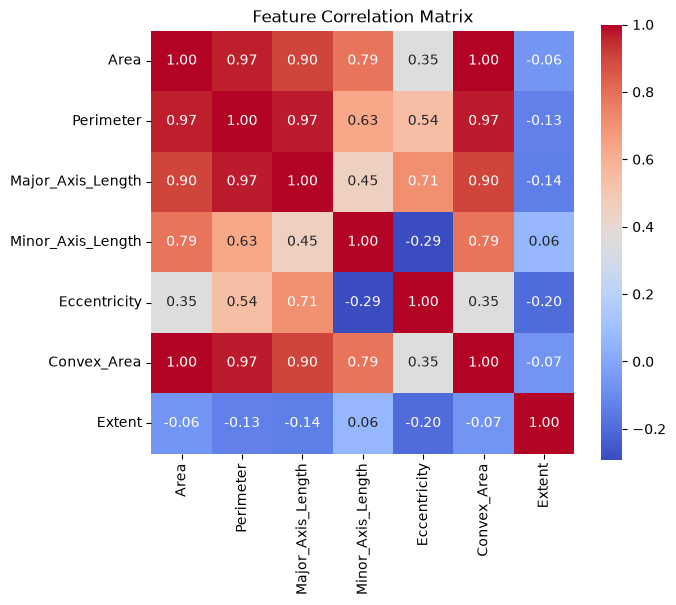

In [4]:
#EDA_Visualization - Correlation_heatmap
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member5_correlation_heatmap.png', dpi=150)
plt.show()


In [5]:
#Rank_features_by_predictive_power_(ANOVA F-test)against_the_target
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

X = df[num_cols]
y = LabelEncoder().fit_transform(df['Class'])

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

scores = pd.Series(selector.scores_, index=num_cols).sort_values(ascending=False)
scores


Major_Axis_Length    8292.132060
Perimeter            7089.384674
Convex_Area          4908.672315
Area                 4790.119949
Eccentricity         2021.961901
Minor_Axis_Length     605.345502
Extent                 53.519198
dtype: float64

In [6]:
#Select_the_top-k_features
k = 5
top_features = scores.head(k).index.tolist()
print("Selected features:", top_features)

X_selected = X[top_features]
X_selected.head()


Selected features: ['Major_Axis_Length', 'Perimeter', 'Convex_Area', 'Area', 'Eccentricity']


,Major_Axis_Length,Perimeter,Convex_Area,Area,Eccentricity
0,229.749878,525.578979,15617.0,15231.0,0.928882
1,206.020065,494.311005,15072.0,14656.0,0.895405
2,214.106781,501.122009,14954.0,14634.0,0.912118
3,193.337387,458.342987,13368.0,13176.0,0.891861
4,211.743378,507.166992,15262.0,14688.0,0.906691
